# California Housing Price Prediction

**Student ID:** 750096984

Unsupervised (K-Means + KNN) and supervised (Linear Regression, Random Forest, SVR, and a Multi-Layer Perceptron) machine learning models to predict the median house value of California districts (1990 U.S. Census data).

**Pipeline:** setup → data loading → EDA → preprocessing & feature engineering → visualisation → train/test split → clustering → classical regression → evaluation & ablations → MLP.

## 1. Setup

Import libraries, fix the random seed for reproducibility, and set plotting defaults.

In [1]:
# Imports, reproducibility seed, and plotting defaults.

import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibility: fix the random seed everywhere so results are
# identical on every rerun (required for a reproducible submission).
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plot defaults — applied once so every figure looks consistent.
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["figure.dpi"] = 100

# Show all dataframe columns when printing (we have 10+).
pd.set_option("display.max_columns", None)

print("Setup complete.")
print("pandas:", pd.__version__, "| numpy:", np.__version__)


Setup complete.
pandas: 3.0.3 | numpy: 2.4.6


## 2. Data Loading

Load the dataset reproducibly: use the local copy if present, otherwise download from the original source.

In [2]:
# Reproducible loader: local copy if present, else download and extract.

import tarfile
import urllib.request

DATA_DIR = "../data"                       # repo's data/ folder
CSV_PATH = os.path.join(DATA_DIR, "housing.csv")
SOURCE_URL = "https://github.com/ageron/data/raw/main/housing.tgz"

def load_housing_data():
    """Return the housing DataFrame, downloading the dataset if needed."""
    if not os.path.exists(CSV_PATH):
        print("Local CSV not found — downloading from source...")
        os.makedirs(DATA_DIR, exist_ok=True)
        tgz_path = os.path.join(DATA_DIR, "housing.tgz")
        urllib.request.urlretrieve(SOURCE_URL, tgz_path)
        with tarfile.open(tgz_path) as tgz:
            tgz.extractall(path=DATA_DIR)
        # The archive extracts to data/housing/housing.csv — move it up.
        extracted = os.path.join(DATA_DIR, "housing", "housing.csv")
        if os.path.exists(extracted):
            os.replace(extracted, CSV_PATH)
        print("Download complete.")
    else:
        print("Loading local copy from", CSV_PATH)
    return pd.read_csv(CSV_PATH)

housing = load_housing_data()
print("Loaded:", housing.shape[0], "rows ×", housing.shape[1], "columns")
housing.head()


Loading local copy from ../data\housing.csv
Loaded: 20640 rows × 10 columns


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## 3. Exploratory Data Analysis

Inspect structure, missing values, distribution artefacts, and categorical balance to inform preprocessing.

In [3]:
# Structure, dtypes, and summary statistics.

print("Dataset shape:", housing.shape)
print("\n--- Column types ---")
print(housing.dtypes)

print("\n--- Summary statistics (numeric features) ---")
display(housing.describe())


Dataset shape: (20640, 10)

--- Column types ---
longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity           str
dtype: object

--- Summary statistics (numeric features) ---


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [4]:
# Missing values per column.

missing = housing.isnull().sum()
missing_pct = (missing / len(housing) * 100).round(2)
missing_table = pd.DataFrame({"missing_count": missing, "missing_%": missing_pct})
print("Missing values per column:")
display(missing_table[missing_table["missing_count"] > 0])

print(f"\nTotal rows: {len(housing)}")
print("Only 'total_bedrooms' has missing values "
      f"({missing['total_bedrooms']} rows, "
      f"{missing_pct['total_bedrooms']}% of data).")


Missing values per column:


,missing_count,missing_%
total_bedrooms,207,1.0



Total rows: 20640
Only 'total_bedrooms' has missing values (207 rows, 1.0% of data).


In [5]:
# Capped-value artefacts: census ceilings that limit achievable accuracy.

target = "median_house_value"
mx_val = housing[target].max()
n_capped = (housing[target] == mx_val).sum()
print(f"Target capped at {mx_val}: {n_capped} rows "
      f"({n_capped/len(housing)*100:.1f}% sit exactly at the ceiling).")

mx_age = housing["housing_median_age"].max()
n_age = (housing["housing_median_age"] == mx_age).sum()
print(f"housing_median_age capped at {mx_age}: {n_age} rows "
      f"({n_age/len(housing)*100:.1f}%).")


Target capped at 500001.0: 965 rows (4.7% sit exactly at the ceiling).
housing_median_age capped at 52.0: 1273 rows (6.2%).


In [6]:
# Categorical feature balance (ocean_proximity).

print("ocean_proximity value counts:")
display(housing["ocean_proximity"].value_counts())

print("\nNote: 'ISLAND' has only 5 records — a rare category that "
      "must be handled carefully in the train/test split and encoding.")


ocean_proximity value counts:


ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


Note: 'ISLAND' has only 5 records — a rare category that must be handled carefully in the train/test split and encoding.


## 4. Preprocessing & Feature Engineering

Row-wise, non-learned transforms are applied now (no leakage risk). Learned transforms (imputation, scaling) are deferred to after the split.

In [7]:
# Feature engineering: per-household ratios.
# Rationale: total_rooms, total_bedrooms and population are block-group totals
# that mostly encode block size; normalising per household yields features that
# correlate more directly with house value (verified in Section 5).

housing = housing.copy()

housing["rooms_per_household"]      = housing["total_rooms"]    / housing["households"]
housing["bedrooms_per_room"]        = housing["total_bedrooms"] / housing["total_rooms"]
housing["population_per_household"]  = housing["population"]      / housing["households"]

print("Added engineered features:")
print(housing[["rooms_per_household", "bedrooms_per_room",
               "population_per_household"]].describe())


Added engineered features:
       rooms_per_household  bedrooms_per_room  population_per_household
count         20640.000000       20433.000000              20640.000000
mean              5.429000           0.213039                  3.070655
std               2.474173           0.057983                 10.386050
min               0.846154           0.100000                  0.692308
25%               4.440716           0.175427                  2.429741
50%               5.229129           0.203162                  2.818116
75%               6.052381           0.239821                  3.282261
max             141.909091           1.000000               1243.333333


In [8]:
# One-hot encode ocean_proximity.
# Rationale: the variable is nominal (no inherent order), so one-hot encoding is
# appropriate; ordinal encoding would impose a false ranking.

housing_encoded = pd.get_dummies(housing, columns=["ocean_proximity"],
                                 prefix="ocean")

# get_dummies produces boolean columns; cast to int for clean numeric handling.
ocean_cols = [c for c in housing_encoded.columns if c.startswith("ocean_")]
housing_encoded[ocean_cols] = housing_encoded[ocean_cols].astype(int)

print("Encoded columns:", ocean_cols)
print("New shape:", housing_encoded.shape)
housing_encoded.head(3)


Encoded columns: ['ocean_<1H OCEAN', 'ocean_INLAND', 'ocean_ISLAND', 'ocean_NEAR BAY', 'ocean_NEAR OCEAN']
New shape: (20640, 17)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,rooms_per_household,bedrooms_per_room,population_per_household,ocean_<1H OCEAN,ocean_INLAND,ocean_ISLAND,ocean_NEAR BAY,ocean_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,6.984127,0.146591,2.555556,0,0,0,1,0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,6.238137,0.155797,2.109842,0,0,0,1,0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,8.288136,0.129516,2.802260,0,0,0,1,0


In [9]:
# Flag capped-target rows (do not drop): used for the ablation in Section 9.
# is_capped is a bookkeeping flag, excluded from the feature matrix X.

CAP_VALUE = housing_encoded["median_house_value"].max()
housing_encoded["is_capped"] = (housing_encoded["median_house_value"] == CAP_VALUE).astype(int)

print(f"Flagged {housing_encoded['is_capped'].sum()} capped rows "
      f"({housing_encoded['is_capped'].mean()*100:.1f}%).")
print("Note: 'is_capped' is a bookkeeping flag for the ablation, NOT a model "
      "feature — it will be excluded from X.")


Flagged 965 capped rows (4.7%).
Note: 'is_capped' is a bookkeeping flag for the ablation, NOT a model feature — it will be excluded from X.


## 5. Visualisation & Feature Analysis

Visualisation supports analysis: quantify feature-target relationships, verify the engineered features, and reveal spatial structure.

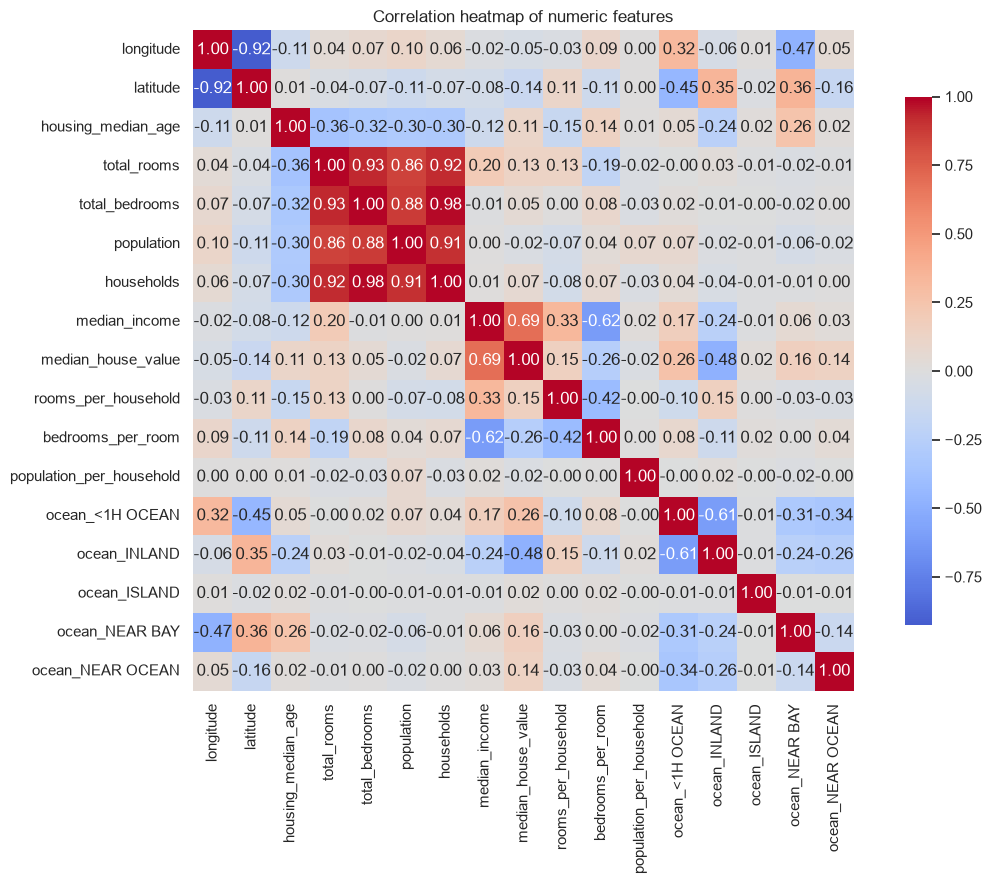

In [10]:
# Correlation heatmap of numeric features.

num_cols = housing_encoded.select_dtypes(include=[np.number]).columns
num_cols = [c for c in num_cols if c != "is_capped"]

corr = housing_encoded[num_cols].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, cbar_kws={"shrink": 0.8})
plt.title("Correlation heatmap of numeric features")
plt.tight_layout()
plt.savefig("../figures/correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


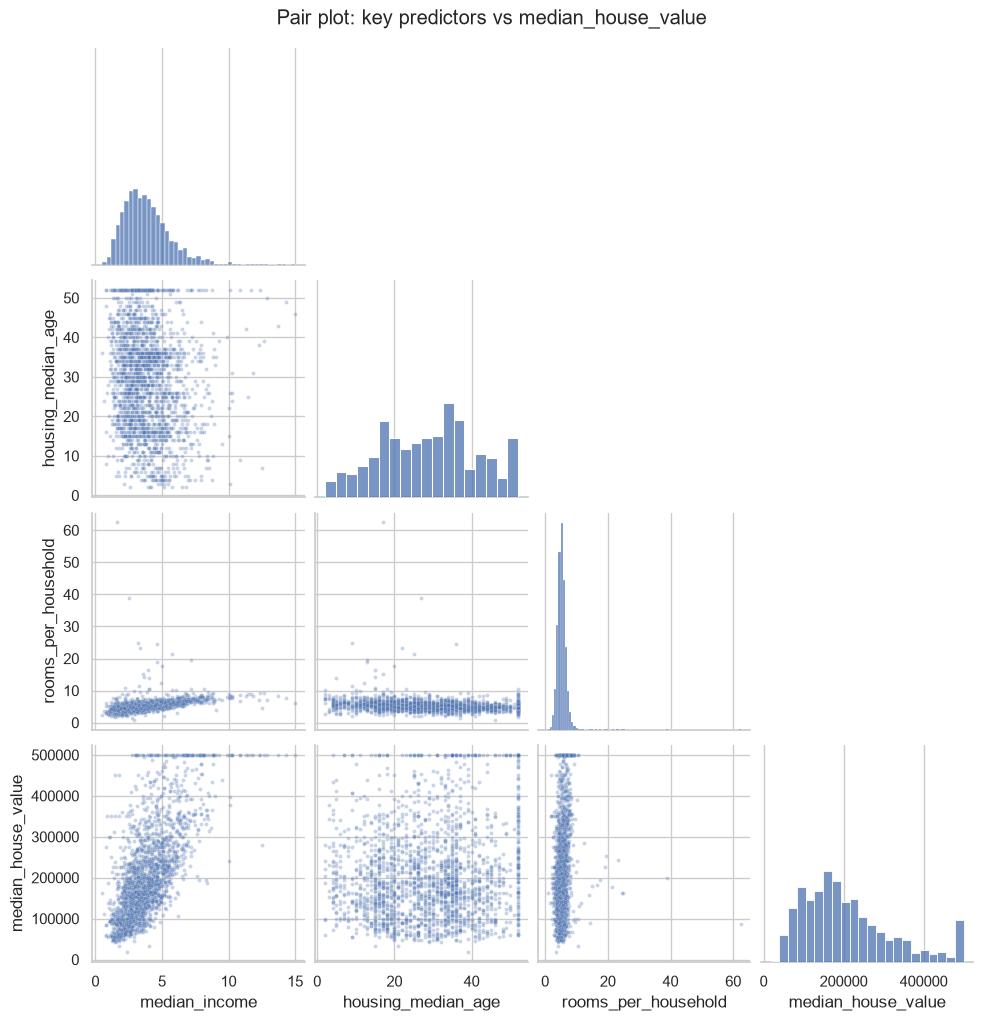

In [11]:
# Pair plot of the strongest predictors vs the target.
# Restricted to the most informative features (a full pair plot of 17 columns is
# unreadable); a fixed-seed sample keeps rendering fast without changing the picture.

pair_cols = ["median_income", "housing_median_age",
             "rooms_per_household", "median_house_value"]
sample = housing_encoded[pair_cols].sample(2000, random_state=RANDOM_STATE)

g = sns.pairplot(sample, corner=True, plot_kws={"s": 8, "alpha": 0.3})
g.fig.suptitle("Pair plot: key predictors vs median_house_value", y=1.02)
g.savefig("../figures/pairplot.png", dpi=150, bbox_inches="tight")
plt.show()

In [12]:
# Verify engineered features: compare each raw total's correlation with the
# target against its per-household ratio.

target = "median_house_value"

pairs = [
    ("total_rooms",    "rooms_per_household"),
    ("total_bedrooms", "bedrooms_per_room"),
    ("population",      "population_per_household"),
]

print(f"{'feature':<28}{'corr with target':>18}")
print("-" * 46)
for raw, ratio in pairs:
    c_raw   = housing_encoded[raw].corr(housing_encoded[target])
    c_ratio = housing_encoded[ratio].corr(housing_encoded[target])
    print(f"{raw:<28}{c_raw:>18.3f}")
    print(f"  -> {ratio:<24}{c_ratio:>18.3f}")
    print()

print("median_income corr with target: "
      f"{housing_encoded['median_income'].corr(housing_encoded[target]):.3f}  "
      "(strongest single predictor)")


feature                       corr with target
----------------------------------------------
total_rooms                              0.134
  -> rooms_per_household                  0.152

total_bedrooms                           0.050
  -> bedrooms_per_room                   -0.256

population                              -0.025
  -> population_per_household            -0.024

median_income corr with target: 0.688  (strongest single predictor)


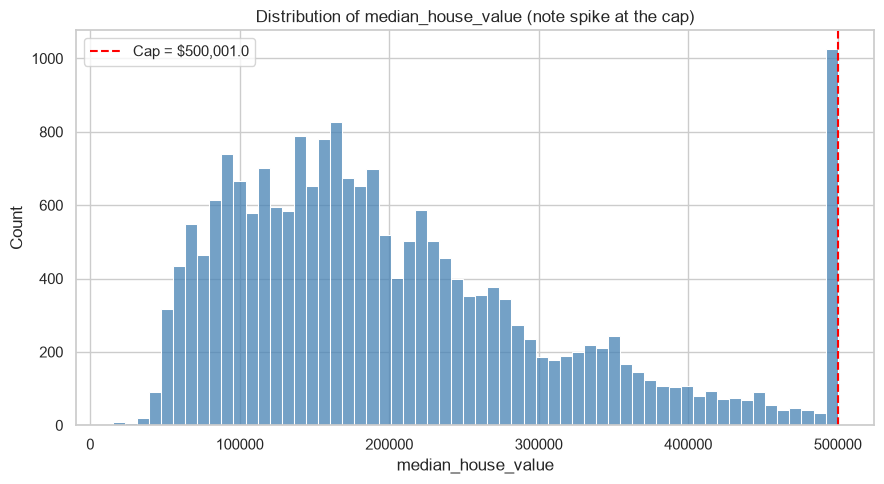

In [13]:
# Target distribution, showing the $500k cap artefact.

plt.figure(figsize=(9, 5))
sns.histplot(housing_encoded[target], bins=60, kde=False, color="steelblue")
plt.axvline(CAP_VALUE, color="red", linestyle="--",
            label=f"Cap = ${CAP_VALUE:,}")
plt.title("Distribution of median_house_value (note spike at the cap)")
plt.xlabel("median_house_value")
plt.legend()
plt.tight_layout()
plt.savefig("../figures/target_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


C:\Users\varus\AppData\Local\Temp\ipykernel_48680\2528823321.py:14: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\varus\AppData\Local\Temp\ipykernel_48680\2528823321.py:15: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  plt.savefig("../figures/geographic_value_map.png", dpi=150, bbox_inches="tight")
c:\Users\varus\anaconda3\envs\ecmm422\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


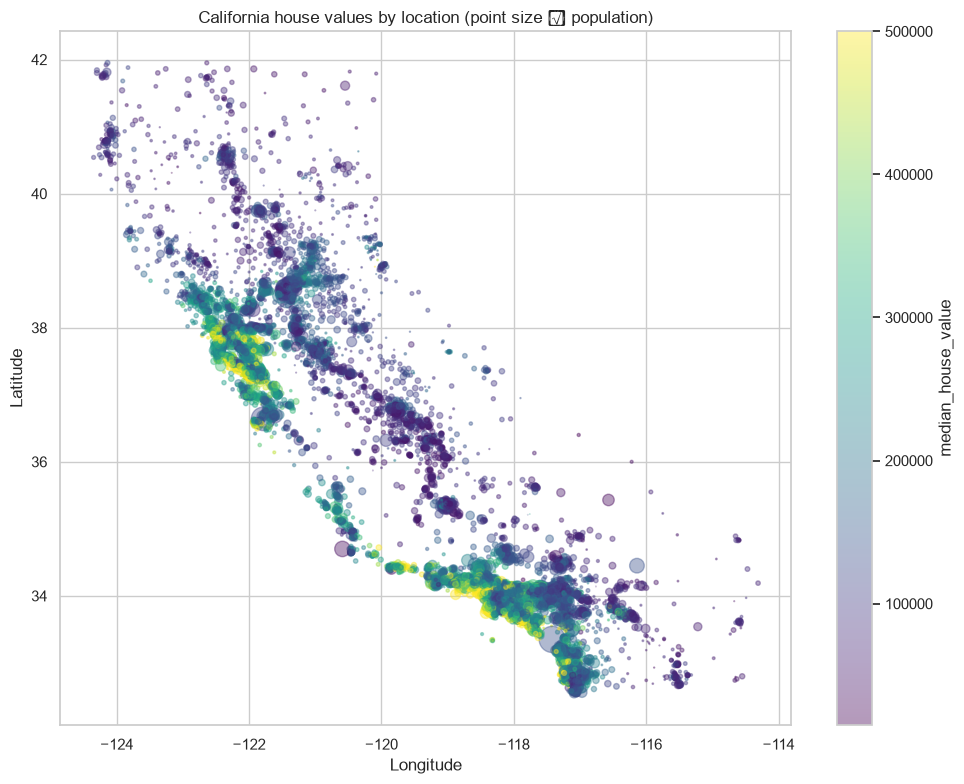

In [14]:
# Geographic scatter of house value: reveals spatial structure that motivates
# using latitude/longitude as clustering features in Section 7.

plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    housing_encoded["longitude"], housing_encoded["latitude"],
    c=housing_encoded[target], cmap="viridis",
    s=housing_encoded["population"] / 100, alpha=0.4
)
plt.colorbar(scatter, label="median_house_value")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("California house values by location (point size ∝ population)")
plt.tight_layout()
plt.savefig("../figures/geographic_value_map.png", dpi=150, bbox_inches="tight")
plt.show()


## 6. Train/Test Split & Leak-Free Preprocessing

Split before fitting any data-dependent transform; fit imputation and scaling on the training set only and apply to test, preventing leakage.

In [15]:
# Separate features X from target y (excluding the is_capped flag); split 80/20.

from sklearn.model_selection import train_test_split

target = "median_house_value"

# Drop the target and the bookkeeping flag from the feature matrix.
# We KEEP is_capped separately so we can align it to the split for the
# later capped-rows ablation.
feature_cols = [c for c in housing_encoded.columns
                if c not in (target, "is_capped")]

X = housing_encoded[feature_cols].copy()
y = housing_encoded[target].copy()
capped_flag = housing_encoded["is_capped"].copy()

X_train, X_test, y_train, y_test, cap_train, cap_test = train_test_split(
    X, y, capped_flag, test_size=0.20, random_state=RANDOM_STATE
)

print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Features:", list(X_train.columns))


Train: (16512, 16) | Test: (4128, 16)
Features: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household', 'ocean_<1H OCEAN', 'ocean_INLAND', 'ocean_ISLAND', 'ocean_NEAR BAY', 'ocean_NEAR OCEAN']


In [16]:
# Median imputation, fit on TRAIN only.
# Median (not mean) because total_bedrooms is right-skewed.

from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

# Fit on training data, transform both sets with the SAME learned medians.
X_train_imp = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns, index=X_train.index
)
X_test_imp = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns, index=X_test.index
)

print("Missing values after imputation:")
print("  train:", int(X_train_imp.isnull().sum().sum()),
      "| test:", int(X_test_imp.isnull().sum().sum()))


Missing values after imputation:
  train: 0 | test: 0


In [17]:
# Standardisation, fit on TRAIN only.
# SVR and the MLP are scale-sensitive and clustering uses Euclidean distance;
# tree models are scale-invariant, so Random Forest uses the unscaled matrices.

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_imp),
    columns=X_train_imp.columns, index=X_train_imp.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_imp),
    columns=X_test_imp.columns, index=X_test_imp.index
)

print("Scaled feature means (train, should be ~0):")
print(X_train_scaled.mean().round(3).head())
print("\nAvailable matrices:")
print("  X_train_imp / X_test_imp       -> unscaled (for Random Forest)")
print("  X_train_scaled / X_test_scaled -> scaled  (for LR, SVR, MLP, clustering)")


Scaled feature means (train, should be ~0):
longitude            -0.0
latitude             -0.0
housing_median_age    0.0
total_rooms           0.0
total_bedrooms        0.0
dtype: float64

Available matrices:
  X_train_imp / X_test_imp       -> unscaled (for Random Forest)
  X_train_scaled / X_test_scaled -> scaled  (for LR, SVR, MLP, clustering)


## 7. Clustering (K-Means + KNN)

Segment housing records into market groups. K-Means is fitted on the training set; KNN assigns cluster labels to the test set (no leakage). The cluster label is added as a feature, and its value is tested by ablation in Section 9.

c:\Users\varus\anaconda3\envs\ecmm422\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


k= 2  inertia=      21513  silhouette=0.5510
k= 3  inertia=      15145  silhouette=0.5212
k= 4  inertia=      11728  silhouette=0.4352
k= 5  inertia=       9441  silhouette=0.3868
k= 6  inertia=       7974  silhouette=0.3993
k= 7  inertia=       6956  silhouette=0.3783
k= 8  inertia=       6172  silhouette=0.3537
k= 9  inertia=       5622  silhouette=0.3619
k=10  inertia=       5137  silhouette=0.3484


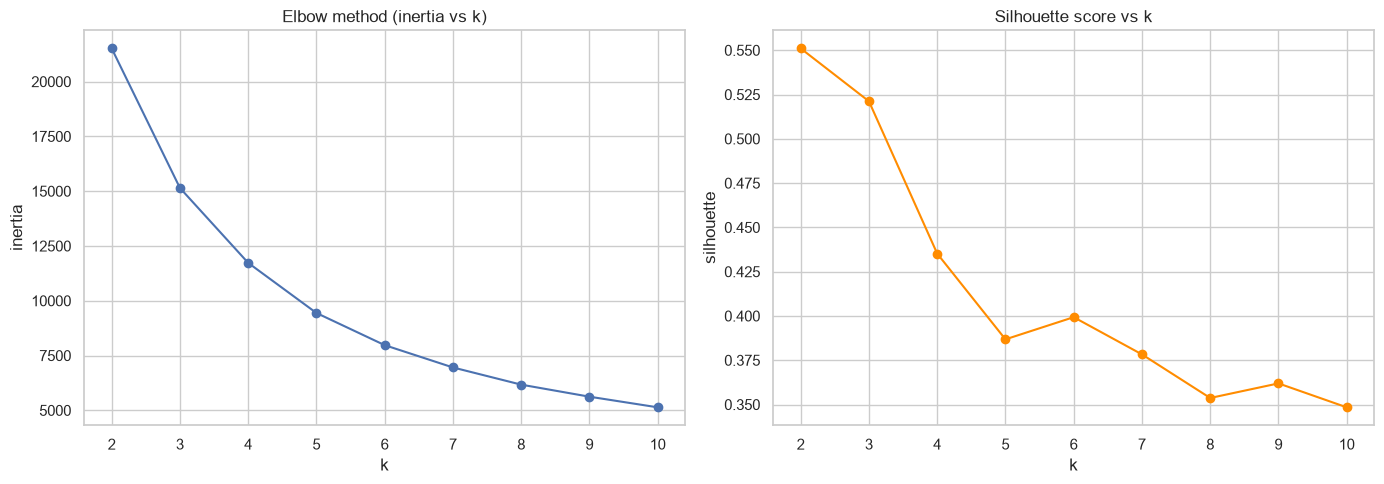

In [18]:
# Choose the number of clusters using the elbow method and silhouette score.
# Clustering features: longitude, latitude, median_income — the dominant value
# drivers identified in Section 5. A focused set yields interpretable segments.

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Focused, interpretable clustering feature set (scaled).
cluster_features = ["longitude", "latitude", "median_income"]
Xc_train = X_train_scaled[cluster_features].values

k_range = range(2, 11)
inertias, silhouettes = [], []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(Xc_train)
    inertias.append(km.inertia_)
    sil = silhouette_score(Xc_train, labels,
                           sample_size=3000, random_state=RANDOM_STATE)
    silhouettes.append(sil)
    print(f"k={k:2d}  inertia={km.inertia_:11.0f}  silhouette={sil:.4f}")

# Plot both diagnostics side by side.
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(list(k_range), inertias, "o-")
ax[0].set(title="Elbow method (inertia vs k)", xlabel="k", ylabel="inertia")
ax[1].plot(list(k_range), silhouettes, "o-", color="darkorange")
ax[1].set(title="Silhouette score vs k", xlabel="k", ylabel="silhouette")
plt.tight_layout()
plt.savefig("../figures/cluster_selection.png", dpi=150, bbox_inches="tight")
plt.show()


In [19]:
# Fit final K-Means (k=3, train only) and interpret clusters.
# k=3 chosen from the elbow while retaining a high silhouette (~0.52); k=2 was
# rejected as a trivial split with little descriptive value.

K_FINAL = 3

kmeans = KMeans(n_clusters=K_FINAL, random_state=RANDOM_STATE, n_init=10)
train_clusters = kmeans.fit_predict(Xc_train)

# Attach labels to a copy of the (unscaled) training data for interpretation.
train_view = X_train_imp.copy()
train_view["cluster"] = train_clusters
train_view["median_house_value"] = y_train.values

print("Cluster sizes:")
print(train_view["cluster"].value_counts().sort_index(), "\n")

print("Cluster profiles (means of key features + target):")
profile = train_view.groupby("cluster")[
    ["median_income", "median_house_value", "longitude", "latitude"]
].mean().round(2)
display(profile)


Cluster sizes:
cluster
0    8043
1    6670
2    1799
Name: count, dtype: int64 

Cluster profiles (means of key features + target):


,median_income,median_house_value,longitude,latitude
cluster,,,,
0,3.26,185042.95,-118.00,33.97
1,3.61,188822.79,-121.72,37.98
2,7.53,364401.83,-118.57,34.33


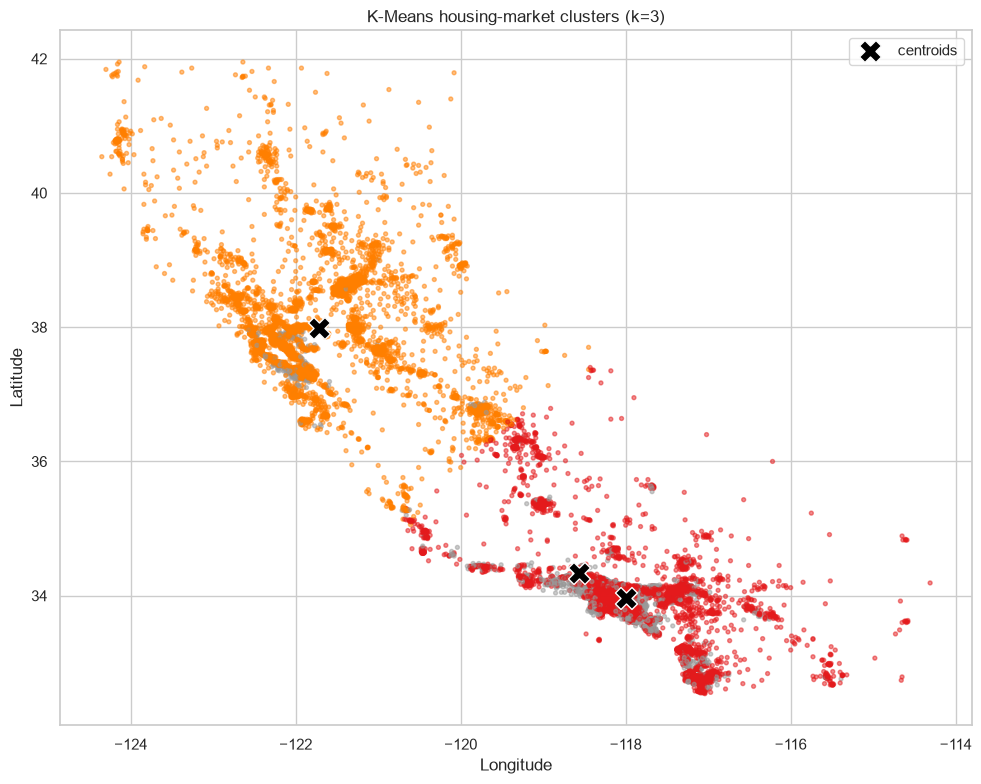

In [20]:
# Geographic visualisation of the clusters across California.

plt.figure(figsize=(10, 8))
sc = plt.scatter(train_view["longitude"], train_view["latitude"],
                 c=train_view["cluster"], cmap="Set1", s=8, alpha=0.5)
plt.scatter(
    kmeans.cluster_centers_[:, 0] * scaler.scale_[X_train_scaled.columns.get_loc("longitude")] + scaler.mean_[X_train_scaled.columns.get_loc("longitude")],
    kmeans.cluster_centers_[:, 1] * scaler.scale_[X_train_scaled.columns.get_loc("latitude")] + scaler.mean_[X_train_scaled.columns.get_loc("latitude")],
    c="black", marker="X", s=250, label="centroids", edgecolors="white"
)
plt.xlabel("Longitude"); plt.ylabel("Latitude")
plt.title(f"K-Means housing-market clusters (k={K_FINAL})")
plt.legend()
plt.tight_layout()
plt.savefig("../figures/cluster_map.png", dpi=150, bbox_inches="tight")
plt.show()


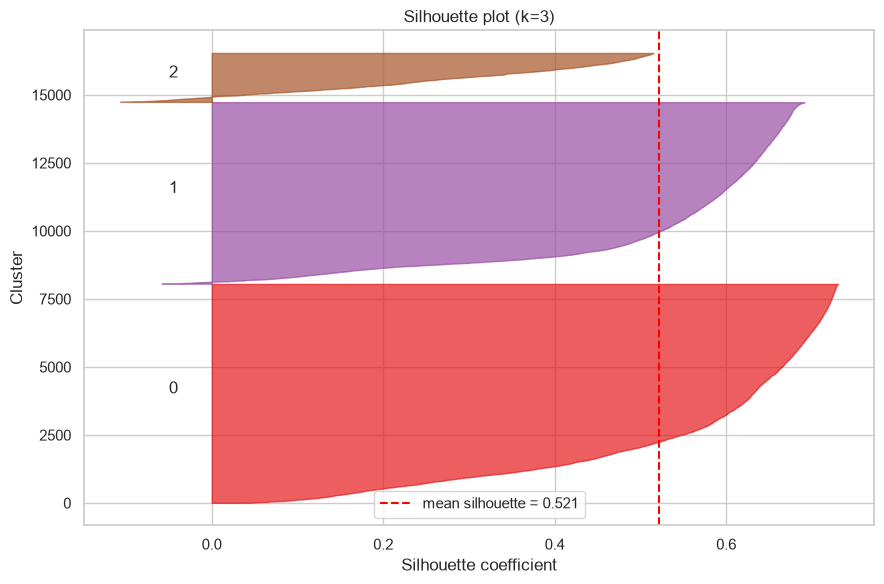

In [21]:
# Silhouette plot for the chosen k (per-sample cluster quality).

from sklearn.metrics import silhouette_samples
import matplotlib.cm as cm

sample_vals = silhouette_samples(Xc_train, train_clusters)
avg_sil = silhouette_score(Xc_train, train_clusters,
                           sample_size=3000, random_state=RANDOM_STATE)

plt.figure(figsize=(9, 6))
y_lower = 10
for i in range(K_FINAL):
    ith = np.sort(sample_vals[train_clusters == i])
    size = ith.shape[0]
    y_upper = y_lower + size
    color = cm.Set1(i / K_FINAL)
    plt.fill_betweenx(np.arange(y_lower, y_upper), 0, ith,
                      facecolor=color, edgecolor=color, alpha=0.7)
    plt.text(-0.05, y_lower + 0.5 * size, str(i))
    y_lower = y_upper + 10
plt.axvline(avg_sil, color="red", linestyle="--",
            label=f"mean silhouette = {avg_sil:.3f}")
plt.xlabel("Silhouette coefficient"); plt.ylabel("Cluster")
plt.title(f"Silhouette plot (k={K_FINAL})")
plt.legend()
plt.tight_layout()
plt.savefig("../figures/silhouette_plot.png", dpi=150, bbox_inches="tight")
plt.show()


In [22]:
# Assign clusters to the TEST set via KNN (K-Means fitted on train only), then
# add the cluster label as a feature to both train and test matrices.

from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(Xc_train, train_clusters)

Xc_test = X_test_scaled[cluster_features].values
test_clusters = knn.predict(Xc_test)

# Add cluster label as a feature (both scaled and unscaled matrices).
X_train_imp    = X_train_imp.assign(cluster=train_clusters)
X_test_imp     = X_test_imp.assign(cluster=test_clusters)
X_train_scaled = X_train_scaled.assign(cluster=train_clusters)
X_test_scaled  = X_test_scaled.assign(cluster=test_clusters)

print("Cluster label added as a feature.")
print("Train cluster distribution:", np.bincount(train_clusters))
print("Test  cluster distribution:", np.bincount(test_clusters))
print("Feature count now:", X_train_imp.shape[1])

# Save the clustering deliverables: the fitted K-Means model (KMC_model) and
# the KNN cluster-assigner used to label unseen records.
import joblib
joblib.dump(kmeans, "../models/KMC_model.joblib")
joblib.dump(knn, "../models/KNN_cluster_assigner.joblib")
print("Saved ../models/KMC_model.joblib and ../models/KNN_cluster_assigner.joblib")


Cluster label added as a feature.
Train cluster distribution: [8043 6670 1799]
Test  cluster distribution: [1968 1691  469]
Feature count now: 17
Saved ../models/KMC_model.joblib and ../models/KNN_cluster_assigner.joblib


## 8. Regression Models (Linear Regression, Random Forest, SVR)

Three regressors evaluated under a shared protocol: 5-fold cross-validation, R²/MAE/RMSE on train and test, and randomised/grid hyperparameter search. LR and SVR use scaled features; Random Forest uses unscaled.

In [23]:
# Shared cross-validation and evaluation helpers for a fair comparison.

from sklearn.model_selection import KFold, cross_validate
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

CV = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Store every model's results here for the Stage 9 comparison.
results = {}

def cv_report(model, X, y, name):
    """5-fold CV on the training set; returns mean ± std for R², MAE, RMSE."""
    scoring = {
        "r2": "r2",
        "mae": "neg_mean_absolute_error",
        "rmse": "neg_root_mean_squared_error",
    }
    cv = cross_validate(model, X, y, cv=CV, scoring=scoring,
                        return_train_score=False, n_jobs=-1)
    out = {
        "cv_r2_mean":  cv["test_r2"].mean(),
        "cv_r2_std":   cv["test_r2"].std(),
        "cv_mae_mean": -cv["test_mae"].mean(),
        "cv_rmse_mean": -cv["test_rmse"].mean(),
        "cv_rmse_scores": -cv["test_rmse"],   # full distribution for boxplots
    }
    print(f"[{name}] 5-fold CV: "
          f"R²={out['cv_r2_mean']:.3f}±{out['cv_r2_std']:.3f} | "
          f"MAE={out['cv_mae_mean']:,.0f} | RMSE={out['cv_rmse_mean']:,.0f}")
    return out

def evaluate_model(model, X_tr, y_tr, X_te, y_te, name):
    """Fit, then report train and test R²/MAE/RMSE. Stores results globally."""
    model.fit(X_tr, y_tr)
    pred_tr, pred_te = model.predict(X_tr), model.predict(X_te)

    def trio(y_true, y_pred):
        return (
            r2_score(y_true, y_pred),
            mean_absolute_error(y_true, y_pred),
            np.sqrt(mean_squared_error(y_true, y_pred)),
        )

    r2_tr, mae_tr, rmse_tr = trio(y_tr, pred_tr)
    r2_te, mae_te, rmse_te = trio(y_te, pred_te)

    results.setdefault(name, {}).update({
        "model": model,
        "r2_train": r2_tr,   "r2_test": r2_te,
        "mae_train": mae_tr, "mae_test": mae_te,
        "rmse_train": rmse_tr, "rmse_test": rmse_te,
        "pred_test": pred_te,
    })

    print(f"[{name}] TRAIN: R²={r2_tr:.3f}  MAE={mae_tr:,.0f}  RMSE={rmse_tr:,.0f}")
    print(f"[{name}] TEST : R²={r2_te:.3f}  MAE={mae_te:,.0f}  RMSE={rmse_te:,.0f}")
    gap = r2_tr - r2_te
    print(f"[{name}] train-test R² gap = {gap:.3f}  "
          f"({'possible overfitting' if gap > 0.1 else 'well generalised'})")
    return model

print("Evaluation helpers ready.")


Evaluation helpers ready.


In [24]:
# Linear Regression: interpretable baseline (no hyperparameters to tune).

from sklearn.linear_model import LinearRegression
import joblib

lr = LinearRegression()

# 5-fold CV on training data
results.setdefault("LR", {}).update(cv_report(lr, X_train_scaled, y_train, "LR"))

# Fit + full train/test evaluation
evaluate_model(lr, X_train_scaled, y_train, X_test_scaled, y_test, "LR")

# Inspect the largest-magnitude coefficients (interpretability).
coef = pd.Series(lr.coef_, index=X_train_scaled.columns).sort_values(key=abs, ascending=False)
print("\nTop linear coefficients (scaled features):")
print(coef.head(8).round(0))

# Save the model deliverable.
joblib.dump(lr, "../models/LR_model.joblib")
print("\nSaved ../models/LR_model.joblib")


[LR] 5-fold CV: R²=0.651±0.020 | MAE=48,711 | RMSE=67,776
[LR] TRAIN: R²=0.654  MAE=48,618  RMSE=67,509
[LR] TEST : R²=0.660  MAE=49,707  RMSE=68,647
[LR] train-test R² gap = -0.006  (well generalised)

Top linear coefficients (scaled features):
median_income         73395.0
latitude             -56821.0
longitude            -52557.0
population           -43833.0
households            40680.0
bedrooms_per_room     15030.0
housing_median_age    13372.0
ocean_INLAND         -11684.0
dtype: float64

Saved ../models/LR_model.joblib


In [25]:
# Random Forest with RandomizedSearchCV.
# Uses unscaled data (tree splits are scale-invariant). The search space spans
# n_estimators, max_depth, max_features, and leaf/split regularisation.

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

rf_space = {
    "n_estimators":      [100, 200, 300, 400, 500],
    "max_depth":         [None, 10, 20, 30, 40],
    "max_features":      ["sqrt", 0.5, 1.0],
    "min_samples_leaf":  [1, 2, 4, 8],
    "min_samples_split": [2, 5, 10],
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=rf_space,
    n_iter=30,
    cv=CV,
    scoring="neg_root_mean_squared_error",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
)

print("Running Random Forest randomised search (this takes a few minutes)...")
rf_search.fit(X_train_imp, y_train)   # UNSCALED

print("\nBest RF params:")
for k, v in rf_search.best_params_.items():
    print(f"  {k}: {v}")
print(f"Best CV RMSE: {-rf_search.best_score_:,.0f}")

rf_best = rf_search.best_estimator_

# CV distribution (for boxplots) + full train/test evaluation, on the BEST model.
results.setdefault("RFR", {}).update(cv_report(rf_best, X_train_imp, y_train, "RFR"))
evaluate_model(rf_best, X_train_imp, y_train, X_test_imp, y_test, "RFR")

joblib.dump(rf_best, "../models/RFR_model.joblib")
print("\nSaved ../models/RFR_model.joblib")


Running Random Forest randomised search (this takes a few minutes)...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best RF params:
  n_estimators: 300
  min_samples_split: 2
  min_samples_leaf: 1
  max_features: 0.5
  max_depth: 20
Best CV RMSE: 48,434
[RFR] 5-fold CV: R²=0.822±0.010 | MAE=32,001 | RMSE=48,434
[RFR] TRAIN: R²=0.973  MAE=12,671  RMSE=18,746
[RFR] TEST : R²=0.824  MAE=32,100  RMSE=49,376
[RFR] train-test R² gap = 0.149  (possible overfitting)

Saved ../models/RFR_model.joblib


In [26]:
# Support Vector Regression (RBF kernel), initial randomised search.
# Uses scaled features.

from sklearn.svm import SVR

svr_space = {
    "C":       [1, 10, 50, 100, 200],
    "gamma":   ["scale", "auto", 0.01, 0.1],
    "epsilon": [0.01, 0.1, 0.5, 1.0],
}

svr_search = RandomizedSearchCV(
    SVR(kernel="rbf"),
    param_distributions=svr_space,
    n_iter=15,
    cv=CV,
    scoring="neg_root_mean_squared_error",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=2,
)

print("Running SVR randomised search (SLOW — may take 10-20+ min)...")
svr_search.fit(X_train_scaled, y_train)   # SCALED

print("\nBest SVR params:")
for k, v in svr_search.best_params_.items():
    print(f"  {k}: {v}")
print(f"Best CV RMSE: {-svr_search.best_score_:,.0f}")

svr_best = svr_search.best_estimator_

results.setdefault("SVR", {}).update(cv_report(svr_best, X_train_scaled, y_train, "SVR"))
evaluate_model(svr_best, X_train_scaled, y_train, X_test_scaled, y_test, "SVR")


Running SVR randomised search (SLOW — may take 10-20+ min)...
Fitting 5 folds for each of 15 candidates, totalling 75 fits

Best SVR params:
  gamma: scale
  epsilon: 0.1
  C: 200
Best CV RMSE: 88,053
[SVR] 5-fold CV: R²=0.411±0.012 | MAE=60,252 | RMSE=88,053
[SVR] TRAIN: R²=0.443  MAE=58,483  RMSE=85,706
[SVR] TEST : R²=0.430  MAE=60,494  RMSE=88,884
[SVR] train-test R² gap = 0.012  (well generalised)


,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",200
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [27]:
# Focused SVR grid over higher gamma / C.
# The initial search underfit (low train and test R²), so a focused grid tests
# whether the issue was search coverage.

from sklearn.model_selection import GridSearchCV

svr_focus = {
    "C":       [50, 100, 300],
    "gamma":   [0.1, 0.3, 0.5],     # higher gamma = more local, less smooth
    "epsilon": [0.1],               # fix epsilon; gamma/C are the key levers
}

svr_grid = GridSearchCV(
    SVR(kernel="rbf"),
    param_grid=svr_focus,
    cv=3,                            # 3-fold to keep this tractable
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=2,
)

print("Focused SVR retune (still slow — ~10-15 min)...")
svr_grid.fit(X_train_scaled, y_train)

print("\nBest focused SVR params:")
for k, v in svr_grid.best_params_.items():
    print(f"  {k}: {v}")
print(f"Best CV RMSE: {-svr_grid.best_score_:,.0f}")

# Only adopt the retuned model if it actually beats the first attempt.
svr_best_v2 = svr_grid.best_estimator_
results.setdefault("SVR", {}).update(cv_report(svr_best_v2, X_train_scaled, y_train, "SVR"))
evaluate_model(svr_best_v2, X_train_scaled, y_train, X_test_scaled, y_test, "SVR")


Focused SVR retune (still slow — ~10-15 min)...
Fitting 3 folds for each of 9 candidates, totalling 27 fits

Best focused SVR params:
  C: 300
  epsilon: 0.1
  gamma: 0.1
Best CV RMSE: 89,071
[SVR] 5-fold CV: R²=0.421±0.011 | MAE=59,227 | RMSE=87,305
[SVR] TRAIN: R²=0.452  MAE=57,551  RMSE=85,011
[SVR] TEST : R²=0.442  MAE=59,483  RMSE=87,987
[SVR] train-test R² gap = 0.010  (well generalised)


,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",0.1
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",300
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [28]:
# SVR with target standardisation.
# The focused grid did not improve SVR, indicating the cause was not search
# coverage but target-scale conditioning: SVR's epsilon tube and C penalty act
# in target units (~$200k). Standardising the target resolves the underfitting.

from sklearn.compose import TransformedTargetRegressor
from sklearn.preprocessing import StandardScaler as TargetScaler
from sklearn.model_selection import GridSearchCV

svr_tt = TransformedTargetRegressor(
    regressor=SVR(kernel="rbf"),
    transformer=TargetScaler()
)

svr_focus = {
    "regressor__C":       [1, 10, 50, 100],
    "regressor__gamma":   ["scale", 0.1, 0.3],
    "regressor__epsilon": [0.01, 0.1],
}

svr_grid = GridSearchCV(
    svr_tt, param_grid=svr_focus, cv=CV,
    scoring="neg_root_mean_squared_error", n_jobs=-1, verbose=2,
)

print("SVR with target scaling (full 5-fold)...")
svr_grid.fit(X_train_scaled, y_train)

print("\nBest SVR params:")
for k, v in svr_grid.best_params_.items():
    print(f"  {k.split('__')[-1]}: {v}")
print(f"Best CV RMSE: {-svr_grid.best_score_:,.0f}")

svr_best_v2 = svr_grid.best_estimator_
results.setdefault("SVR", {}).update(cv_report(svr_best_v2, X_train_scaled, y_train, "SVR"))
evaluate_model(svr_best_v2, X_train_scaled, y_train, X_test_scaled, y_test, "SVR")

joblib.dump(svr_best_v2, "../models/SVR_model.joblib")
print("\nSaved ../models/SVR_model.joblib (final)")


SVR with target scaling (full 5-fold)...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best SVR params:
  C: 10
  epsilon: 0.1
  gamma: 0.1
Best CV RMSE: 53,552
[SVR] 5-fold CV: R²=0.782±0.015 | MAE=35,183 | RMSE=53,552
[SVR] TRAIN: R²=0.830  MAE=30,140  RMSE=47,371
[SVR] TEST : R²=0.784  MAE=35,360  RMSE=54,690
[SVR] train-test R² gap = 0.045  (well generalised)

Saved ../models/SVR_model.joblib (final)


## 9. Evaluation, Comparison & Residual Analysis

Compare the classical models, inspect residuals, measure feature importance, run two controlled ablations, and plot learning curves.

In [29]:
# Consolidated metric comparison table for the classical models.

rows = []
for name in ["LR", "RFR", "SVR"]:
    r = results[name]
    rows.append({
        "Model": name,
        "R2_train":  round(r["r2_train"], 3),
        "R2_test":   round(r["r2_test"], 3),
        "RMSE_train": round(r["rmse_train"]),
        "RMSE_test":  round(r["rmse_test"]),
        "MAE_test":   round(r["mae_test"]),
        "R2_gap":    round(r["r2_train"] - r["r2_test"], 3),
    })

comparison = pd.DataFrame(rows).set_index("Model")
print("Classical model comparison (Part 1):")
display(comparison)

comparison.to_csv("../figures/model_comparison_part1.csv")
print("\nSaved comparison table to figures/model_comparison_part1.csv")


Classical model comparison (Part 1):


,R2_train,R2_test,RMSE_train,RMSE_test,MAE_test,R2_gap
Model,,,,,,
LR,0.654,0.660,67509,68647,49707,-0.006
RFR,0.973,0.824,18746,49376,32100,0.149
SVR,0.830,0.784,47371,54690,35360,0.045



Saved comparison table to figures/model_comparison_part1.csv


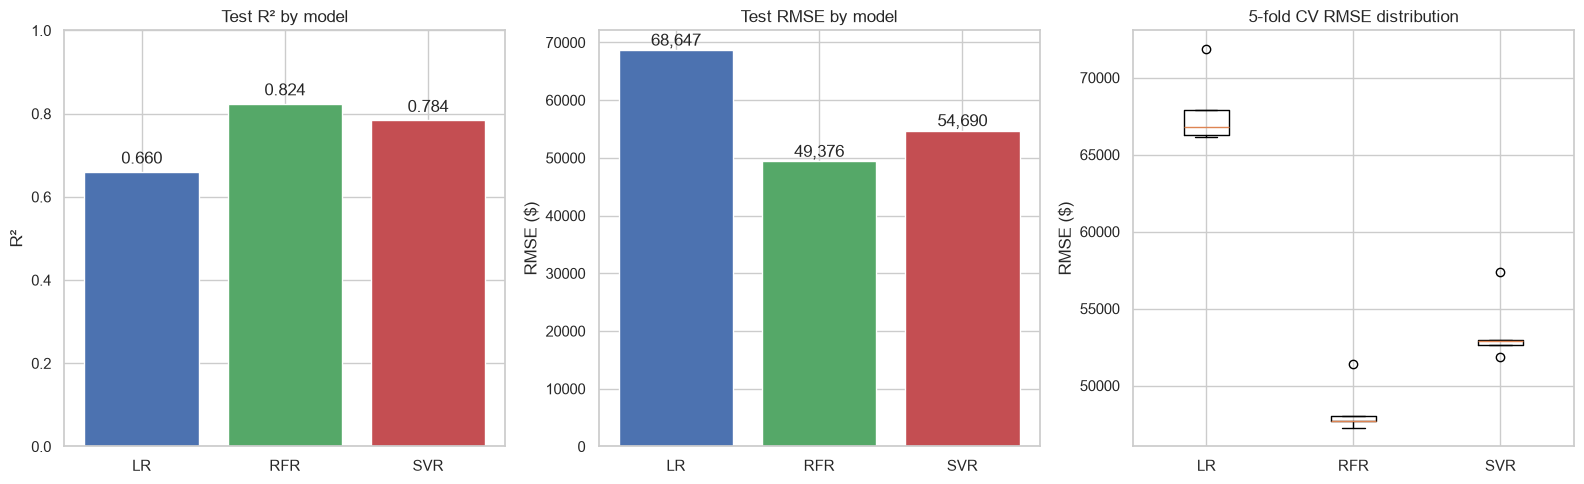

In [30]:
# Visual comparison: test R², test RMSE, and 5-fold CV RMSE distribution.

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

names = ["LR", "RFR", "SVR"]
colours = ["#4C72B0", "#55A868", "#C44E52"]

# (1) Test R²
axes[0].bar(names, [results[n]["r2_test"] for n in names], color=colours)
axes[0].set(title="Test R² by model", ylabel="R²", ylim=(0, 1))
for i, n in enumerate(names):
    axes[0].text(i, results[n]["r2_test"] + 0.02,
                 f'{results[n]["r2_test"]:.3f}', ha="center")

# (2) Test RMSE
axes[1].bar(names, [results[n]["rmse_test"] for n in names], color=colours)
axes[1].set(title="Test RMSE by model", ylabel="RMSE ($)")
for i, n in enumerate(names):
    axes[1].text(i, results[n]["rmse_test"] + 800,
                 f'{results[n]["rmse_test"]:,.0f}', ha="center")

# (3) CV RMSE distribution (box plot) — stability across folds
cv_data = [results[n]["cv_rmse_scores"] for n in names]
axes[2].boxplot(cv_data, tick_labels=names)
axes[2].set(title="5-fold CV RMSE distribution", ylabel="RMSE ($)")

plt.tight_layout()
plt.savefig("../figures/model_comparison_charts.png", dpi=150, bbox_inches="tight")
plt.show()


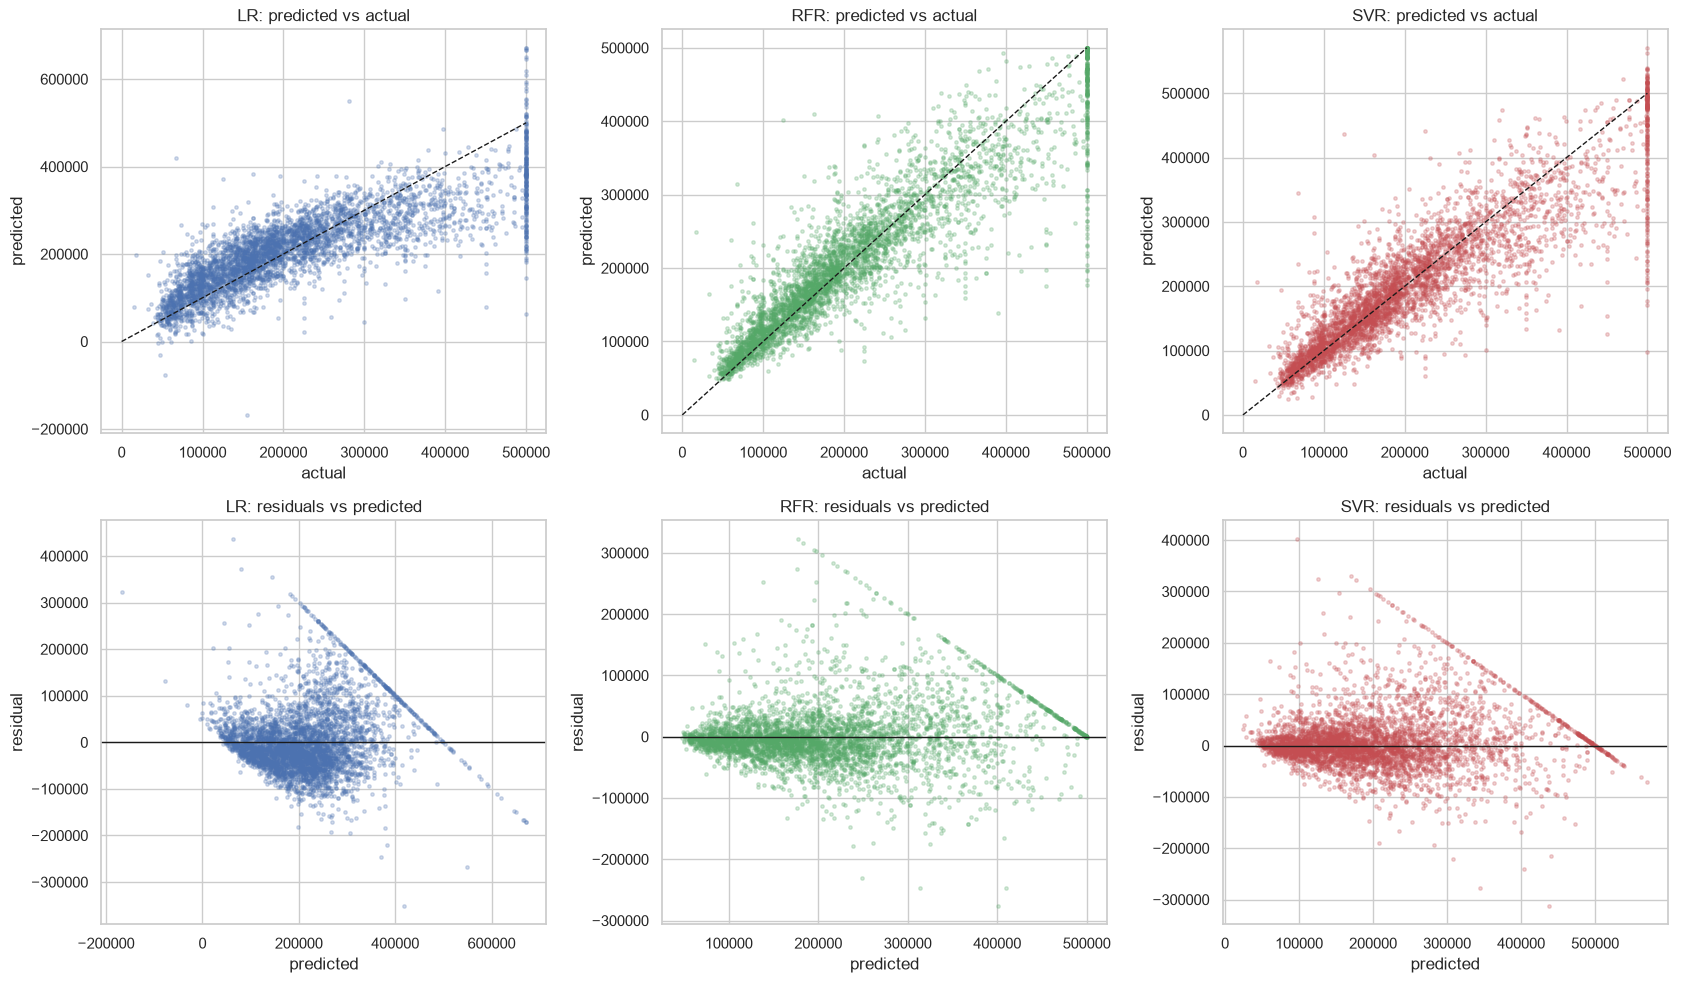

In [31]:
# Actual-vs-predicted and residual plots (test set).
# The band near $500k reflects the target cap; a widening residual spread
# indicates heteroscedasticity at the top of the market.

fig, axes = plt.subplots(2, 3, figsize=(17, 10))

for j, name in enumerate(names):
    pred = results[name]["pred_test"]
    resid = y_test.values - pred

    # Actual vs predicted
    axes[0, j].scatter(y_test, pred, s=6, alpha=0.25, color=colours[j])
    lims = [0, 500001]
    axes[0, j].plot(lims, lims, "k--", lw=1)
    axes[0, j].set(title=f"{name}: predicted vs actual",
                   xlabel="actual", ylabel="predicted")

    # Residuals vs predicted
    axes[1, j].scatter(pred, resid, s=6, alpha=0.25, color=colours[j])
    axes[1, j].axhline(0, color="k", lw=1)
    axes[1, j].set(title=f"{name}: residuals vs predicted",
                   xlabel="predicted", ylabel="residual")

plt.tight_layout()
plt.savefig("../figures/residual_analysis.png", dpi=150, bbox_inches="tight")
plt.show()


### 9.4 Permutation Importance & Controlled Ablations

Measure which features each model relies on, then test two assumptions empirically: the value of the cluster label, and the effect of the capped records.

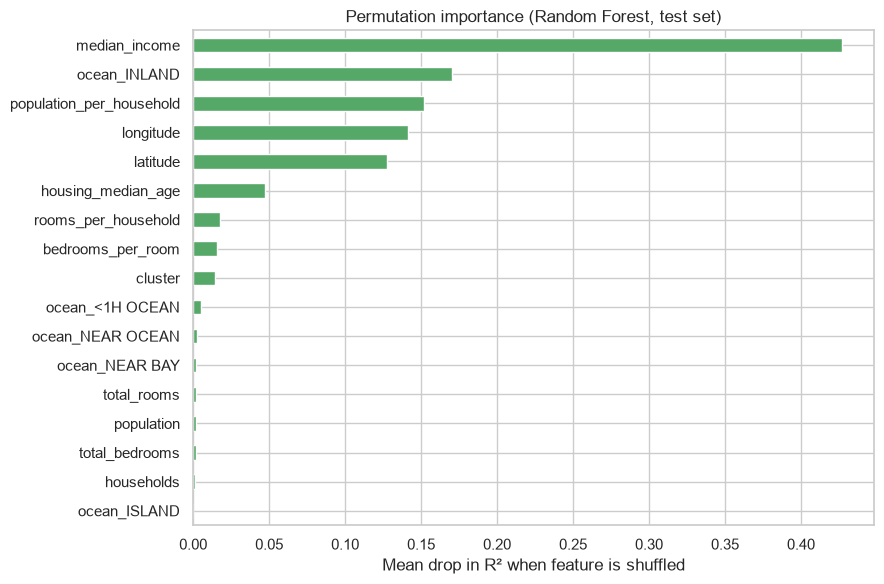

Most important features (descending):
median_income               0.4267
ocean_INLAND                0.1704
population_per_household    0.1522
longitude                   0.1413
latitude                    0.1275
housing_median_age          0.0472
rooms_per_household         0.0175
bedrooms_per_room           0.0155
cluster                     0.0142
ocean_<1H OCEAN             0.0048
dtype: float64


In [32]:
# Permutation importance (Random Forest, test set): the drop in R² when each
# feature is shuffled, revealing how much the model relies on it.

from sklearn.inspection import permutation_importance

rf_model = results["RFR"]["model"]

perm = permutation_importance(
    rf_model, X_test_imp, y_test,
    scoring="r2",                 # <-- explicit metric is the fix
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

imp = pd.Series(perm.importances_mean, index=X_test_imp.columns).sort_values()

plt.figure(figsize=(9, 6))
imp.plot.barh(color="#55A868")
plt.title("Permutation importance (Random Forest, test set)")
plt.xlabel("Mean drop in R² when feature is shuffled")
plt.tight_layout()
plt.savefig("../figures/permutation_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print("Most important features (descending):")
print(imp.sort_values(ascending=False).round(4).head(10))


In [33]:
# Ablation 1 - cluster label: retrain each model with vs without the cluster
# feature to test whether it improves prediction.

from sklearn.base import clone

def fit_score(model, Xtr, ytr, Xte, yte):
    m = clone(model)
    m.fit(Xtr, ytr)
    p = m.predict(Xte)
    return r2_score(yte, p), np.sqrt(mean_squared_error(yte, p))

# Feature sets: with cluster (current) vs without.
cols_with = list(X_train_imp.columns)                       # includes 'cluster'
cols_without = [c for c in cols_with if c != "cluster"]

# Base (untuned-but-reasonable) estimators for a fair, fast like-for-like test.
# We reuse the TUNED hyperparameters so the comparison reflects the real models.
ablation_models = {
    "LR":  (LinearRegression(),                                 "scaled"),
    "RFR": (clone(results["RFR"]["model"]),                     "imp"),
    "SVR": (clone(results["SVR"]["model"]),                     "scaled"),
}

print(f"{'Model':<5}{'with cluster':>16}{'without cluster':>18}{'Δ R²':>10}")
print("-" * 49)
for name, (mdl, kind) in ablation_models.items():
    if kind == "imp":
        Xtr, Xte = X_train_imp, X_test_imp
    else:
        Xtr, Xte = X_train_scaled, X_test_scaled

    r2_with, _  = fit_score(mdl, Xtr[cols_with],    y_train, Xte[cols_with],    y_test)
    r2_wout, _  = fit_score(mdl, Xtr[cols_without], y_train, Xte[cols_without], y_test)
    print(f"{name:<5}{r2_with:>16.4f}{r2_wout:>18.4f}{r2_with - r2_wout:>+10.4f}")


Model    with cluster   without cluster      Δ R²
-------------------------------------------------
LR             0.6601            0.6586   +0.0015
RFR            0.8241            0.8237   +0.0004
SVR            0.7842            0.7848   -0.0006


In [34]:
# Ablation 2 - capped records: train without the $500k-capped rows and compare,
# testing whether removing the artefact improves performance.

keep_train = (cap_train == 0).values          # non-capped training rows
keep_test  = (cap_test  == 0).values          # non-capped test rows

def eval_capped(model_proto, Xtr_full, Xte_full, kind):
    m = clone(model_proto)
    # Train WITHOUT capped rows
    m.fit(Xtr_full[keep_train], y_train[keep_train])

    # (a) score on full test set
    p_full = m.predict(Xte_full)
    r2_full = r2_score(y_test, p_full)
    # (b) score on non-capped test set only
    p_nc = m.predict(Xte_full[keep_test])
    r2_nc = r2_score(y_test[keep_test], p_nc)
    return r2_full, r2_nc

print(f"{'Model':<5}{'baseline(full)':>16}{'no-cap train,':>16}{'no-cap train,':>16}")
print(f"{'':<5}{'':>16}{'full test':>16}{'non-cap test':>16}")
print("-" * 53)
for name in ["LR", "RFR", "SVR"]:
    proto = results[name]["model"]
    Xtr = X_train_imp if name == "RFR" else X_train_scaled
    Xte = X_test_imp  if name == "RFR" else X_test_scaled

    baseline = results[name]["r2_test"]                 # trained WITH capped rows, full test
    r2_full, r2_nc = eval_capped(proto, Xtr, Xte, name)
    print(f"{name:<5}{baseline:>16.4f}{r2_full:>16.4f}{r2_nc:>16.4f}")


Model  baseline(full)   no-cap train,   no-cap train,
                            full test    non-cap test
-----------------------------------------------------
LR             0.6601          0.6515          0.6329
RFR            0.8241          0.8014          0.8033
SVR            0.7842          0.7560          0.7593


### 9.5 Learning Curves

Plot training and cross-validation error against training-set size to diagnose whether each model is bias-limited (curves converge high) or variance-limited (a persistent gap).

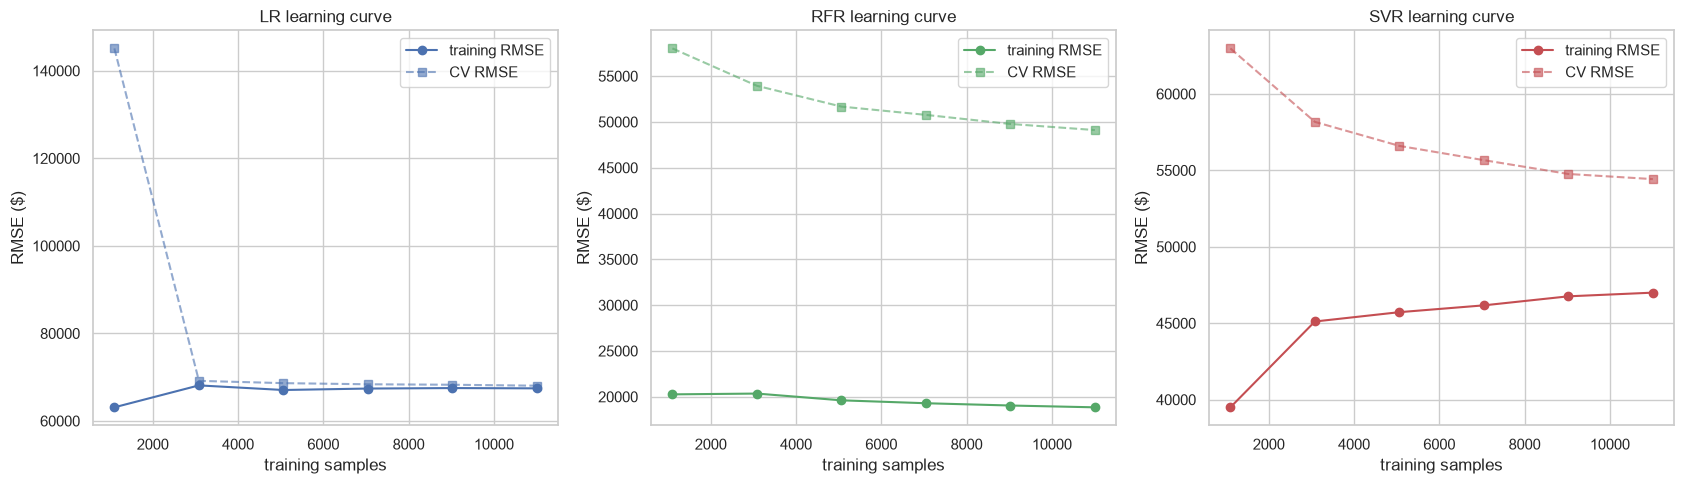

Learning curves saved. Interpretation guide:
 - LR:  train & CV converge HIGH  -> bias-limited (underfit).
 - RFR: large persistent GAP      -> variance-limited (overfit).
 - SVR: moderate gap, converging  -> balanced.


In [35]:
# Learning curves for the three classical models (train vs CV RMSE vs data size).

from sklearn.model_selection import learning_curve

lc_models = {
    "LR":  (clone(results["LR"]["model"]),  X_train_scaled, "#4C72B0"),
    "RFR": (clone(results["RFR"]["model"]), X_train_imp,    "#55A868"),
    "SVR": (clone(results["SVR"]["model"]), X_train_scaled, "#C44E52"),
}

train_sizes = np.linspace(0.1, 1.0, 6)   # 10% .. 100% of training data

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, (name, (mdl, Xmat, colour)) in zip(axes, lc_models.items()):
    sizes, train_scores, val_scores = learning_curve(
        mdl, Xmat, y_train,
        train_sizes=train_sizes, cv=3,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1, random_state=RANDOM_STATE
    )
    train_rmse = -train_scores.mean(axis=1)
    val_rmse   = -val_scores.mean(axis=1)

    ax.plot(sizes, train_rmse, "o-", color=colour, label="training RMSE")
    ax.plot(sizes, val_rmse,  "s--", color=colour, alpha=0.6, label="CV RMSE")
    ax.set(title=f"{name} learning curve", xlabel="training samples",
           ylabel="RMSE ($)")
    ax.legend()

plt.tight_layout()
plt.savefig("../figures/learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()

print("Learning curves saved. Interpretation guide:")
print(" - LR:  train & CV converge HIGH  -> bias-limited (underfit).")
print(" - RFR: large persistent GAP      -> variance-limited (overfit).")
print(" - SVR: moderate gap, converging  -> balanced.")


## 10. Multi-Layer Perceptron (Part 2)

An MLP regressor on the same train/test split. Inputs and target are standardised; the architecture is selected by cross-validated search; regularisation is applied and its effect measured; the model is compared against the Part 1 models.

In [36]:
# Keras setup and full reproducibility (Python, NumPy and TensorFlow seeds).
# Convert to float32 arrays for Keras.

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Seed everything for reproducibility.
tf.random.set_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print("TensorFlow:", tf.__version__)
print("Training features:", X_train_scaled.shape[1])

# Keras works best with float32 numpy arrays.
X_tr = X_train_scaled.values.astype("float32")
X_te = X_test_scaled.values.astype("float32")
y_tr = y_train.values.astype("float32")
y_te = y_test.values.astype("float32")

print("Arrays ready:", X_tr.shape, X_te.shape)


TensorFlow: 2.21.0
Training features: 17
Arrays ready: (16512, 17) (4128, 17)


Final epoch — train RMSE: 44,315 | val RMSE: 54,823


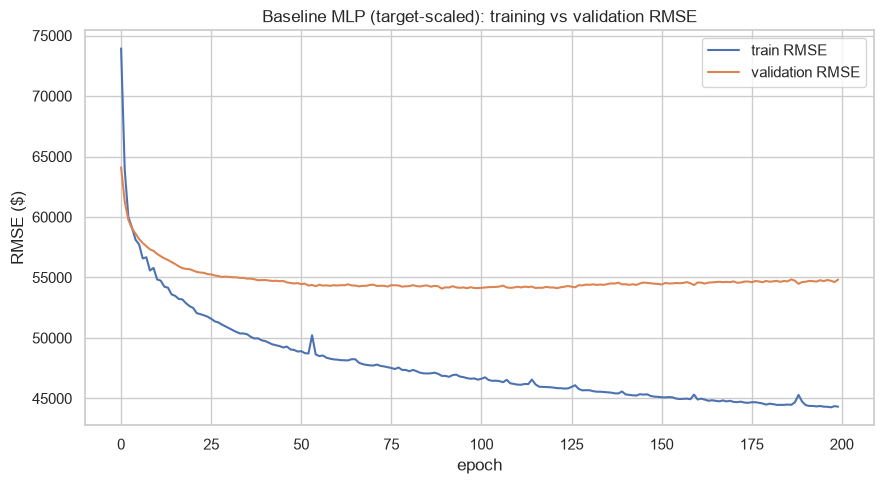

Baseline MLP TEST: R²=0.784  RMSE=54,714  MAE=37,154


In [37]:
# Baseline MLP with standardised target.
# The target (~$200k) is standardised so the MSE loss and gradients are well
# conditioned for Adam; predictions are inverted back to dollars for evaluation.
# Trained without regularisation first so the train/val gap is visible.

from sklearn.preprocessing import StandardScaler

# Scale the target (fit on TRAIN only — no leakage).
y_scaler = StandardScaler()
y_tr_scaled = y_scaler.fit_transform(y_tr.reshape(-1, 1)).ravel()

def build_mlp(dropout_rate=0.0, l2=0.0):
    reg = keras.regularizers.l2(l2) if l2 > 0 else None
    model = keras.Sequential([keras.Input(shape=(X_tr.shape[1],))])
    model.add(layers.Dense(64, activation="relu", kernel_regularizer=reg))
    if dropout_rate > 0:
        model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(32, activation="relu", kernel_regularizer=reg))
    if dropout_rate > 0:
        model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(1))
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3),
                  loss="mse", metrics=["mae"])
    return model

tf.random.set_seed(RANDOM_STATE)
mlp_base = build_mlp(dropout_rate=0.0, l2=0.0)

history_base = mlp_base.fit(
    X_tr, y_tr_scaled,            # train on SCALED target
    validation_split=0.2,
    epochs=200,
    batch_size=64,
    verbose=0
)

# Helper: predict and invert the target scaling back to dollars.
def mlp_predict_dollars(model, X):
    p_scaled = model.predict(X, verbose=0).ravel()
    return y_scaler.inverse_transform(p_scaled.reshape(-1, 1)).ravel()

# Convergence check (convert scaled-loss RMSE back to dollars via target std).
target_std = y_scaler.scale_[0]
final_train_rmse = np.sqrt(history_base.history["loss"][-1]) * target_std
final_val_rmse   = np.sqrt(history_base.history["val_loss"][-1]) * target_std
print(f"Final epoch — train RMSE: {final_train_rmse:,.0f} | val RMSE: {final_val_rmse:,.0f}")

plt.figure(figsize=(9, 5))
plt.plot(np.sqrt(history_base.history["loss"]) * target_std, label="train RMSE")
plt.plot(np.sqrt(history_base.history["val_loss"]) * target_std, label="validation RMSE")
plt.title("Baseline MLP (target-scaled): training vs validation RMSE")
plt.xlabel("epoch"); plt.ylabel("RMSE ($)"); plt.legend()
plt.tight_layout()
plt.savefig("../figures/mlp_baseline_curves.png", dpi=150, bbox_inches="tight")
plt.show()

base_pred = mlp_predict_dollars(mlp_base, X_te)
print(f"Baseline MLP TEST: R²={r2_score(y_te, base_pred):.3f}  "
      f"RMSE={np.sqrt(mean_squared_error(y_te, base_pred)):,.0f}  "
      f"MAE={mean_absolute_error(y_te, base_pred):,.0f}")


Early stopping halted at epoch 175 (best weights restored).
Regularised — train RMSE: 52,602 | val RMSE: 51,973


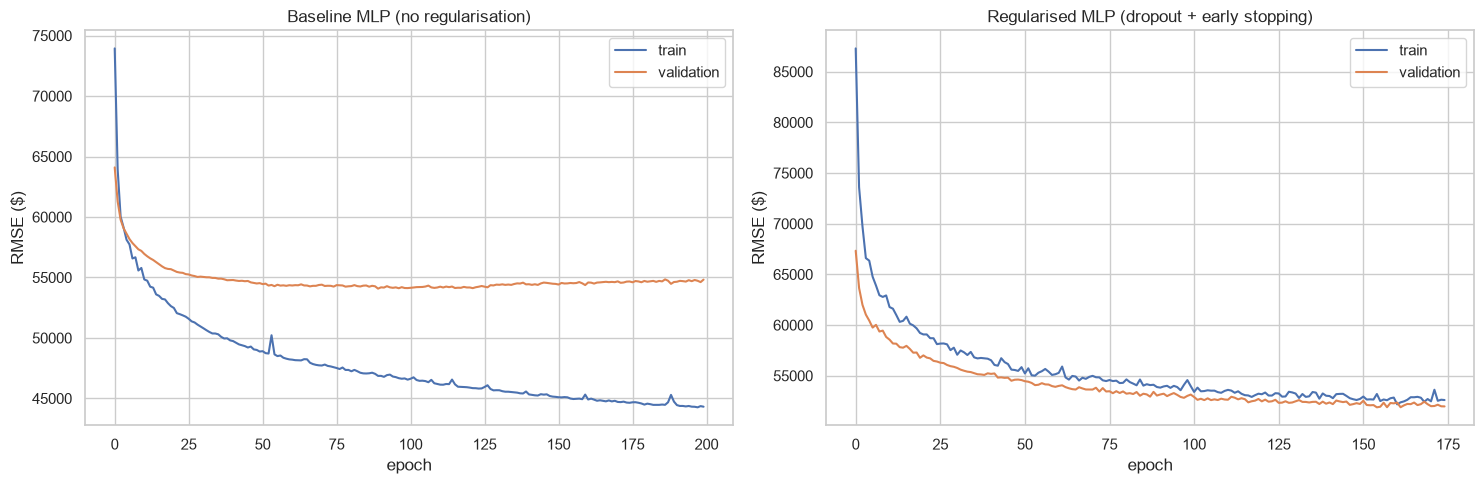


Regularised MLP TEST: R²=0.798  RMSE=52,894  MAE=35,603

--- Regularisation effect (train/val RMSE gap) ---
Baseline    gap: 10,507
Regularised gap: 628


In [38]:
# Regularised MLP: dropout + early stopping, same architecture as the baseline.
# Dropout prevents co-adaptation (reducing variance); early stopping halts once
# validation loss plateaus. Compared head-to-head against the baseline gap.

from tensorflow.keras.callbacks import EarlyStopping

tf.random.set_seed(RANDOM_STATE)
mlp_reg = build_mlp(dropout_rate=0.2, l2=0.0)

early_stop = EarlyStopping(
    monitor="val_loss", patience=20,
    restore_best_weights=True, verbose=0
)

history_reg = mlp_reg.fit(
    X_tr, y_tr_scaled,
    validation_split=0.2,
    epochs=300,                 # high cap; early stopping decides when to halt
    batch_size=64,
    callbacks=[early_stop],
    verbose=0
)

stopped_epoch = len(history_reg.history["loss"])
print(f"Early stopping halted at epoch {stopped_epoch} "
      f"(best weights restored).")

# Convergence numbers in dollars.
reg_train_rmse = np.sqrt(history_reg.history["loss"][-1]) * target_std
reg_val_rmse   = np.sqrt(history_reg.history["val_loss"][-1]) * target_std
print(f"Regularised — train RMSE: {reg_train_rmse:,.0f} | val RMSE: {reg_val_rmse:,.0f}")

# Side-by-side curves: baseline vs regularised.
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].plot(np.sqrt(history_base.history["loss"]) * target_std, label="train")
ax[0].plot(np.sqrt(history_base.history["val_loss"]) * target_std, label="validation")
ax[0].set(title="Baseline MLP (no regularisation)", xlabel="epoch", ylabel="RMSE ($)")
ax[0].legend()
ax[1].plot(np.sqrt(history_reg.history["loss"]) * target_std, label="train")
ax[1].plot(np.sqrt(history_reg.history["val_loss"]) * target_std, label="validation")
ax[1].set(title="Regularised MLP (dropout + early stopping)", xlabel="epoch", ylabel="RMSE ($)")
ax[1].legend()
plt.tight_layout()
plt.savefig("../figures/mlp_regularisation_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# Test performance of the regularised model.
reg_pred = mlp_predict_dollars(mlp_reg, X_te)
print(f"\nRegularised MLP TEST: R²={r2_score(y_te, reg_pred):.3f}  "
      f"RMSE={np.sqrt(mean_squared_error(y_te, reg_pred)):,.0f}  "
      f"MAE={mean_absolute_error(y_te, reg_pred):,.0f}")

# Direct comparison of the train/val gap (the overfitting metric).
print("\n--- Regularisation effect (train/val RMSE gap) ---")
print(f"Baseline    gap: {abs(final_val_rmse - final_train_rmse):,.0f}")
print(f"Regularised gap: {abs(reg_val_rmse - reg_train_rmse):,.0f}")


### 10e. MLP Architecture Search

Select the architecture empirically: a compact grid over width/depth, learning rate, and dropout is scored by 3-fold CV RMSE, and the best design is retrained as the final MLP.

In [39]:
# Architecture search via 3-fold CV over a compact grid (width/depth, learning
# rate, dropout), scored by mean CV RMSE on the standardised target.

from sklearn.model_selection import KFold

def make_mlp(layer_sizes, lr, dropout):
    model = keras.Sequential([keras.Input(shape=(X_tr.shape[1],))])
    for units in layer_sizes:
        model.add(layers.Dense(units, activation="relu"))
        if dropout > 0:
            model.add(layers.Dropout(dropout))
    model.add(layers.Dense(1))
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr), loss="mse")
    return model

# Compact, justified configuration grid.
configs = [
    {"layers": [64, 32],       "lr": 1e-3, "dropout": 0.1},
    {"layers": [64, 32],       "lr": 1e-3, "dropout": 0.2},
    {"layers": [128, 64],      "lr": 1e-3, "dropout": 0.1},
    {"layers": [128, 64],      "lr": 5e-4, "dropout": 0.2},
    {"layers": [128, 64, 32],  "lr": 1e-3, "dropout": 0.2},
    {"layers": [128, 64, 32],  "lr": 5e-4, "dropout": 0.1},
]

kf = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
search_results = []

for i, cfg in enumerate(configs):
    fold_rmses = []
    for tr_idx, val_idx in kf.split(X_tr):
        tf.random.set_seed(RANDOM_STATE)
        model = make_mlp(cfg["layers"], cfg["lr"], cfg["dropout"])
        es = keras.callbacks.EarlyStopping(monitor="val_loss", patience=15,
                                           restore_best_weights=True, verbose=0)
        model.fit(
            X_tr[tr_idx], y_tr_scaled[tr_idx],
            validation_data=(X_tr[val_idx], y_tr_scaled[val_idx]),
            epochs=150, batch_size=64, callbacks=[es], verbose=0
        )
        # Predict on the fold's validation set, score in DOLLARS.
        pred_scaled = model.predict(X_tr[val_idx], verbose=0).ravel()
        pred_dollars = y_scaler.inverse_transform(pred_scaled.reshape(-1, 1)).ravel()
        true_dollars = y_scaler.inverse_transform(y_tr_scaled[val_idx].reshape(-1, 1)).ravel()
        fold_rmses.append(np.sqrt(mean_squared_error(true_dollars, pred_dollars)))

    mean_rmse = np.mean(fold_rmses)
    std_rmse = np.std(fold_rmses)
    search_results.append({**cfg, "cv_rmse": mean_rmse, "cv_std": std_rmse})
    print(f"[{i+1}/{len(configs)}] layers={cfg['layers']}, lr={cfg['lr']}, "
          f"dropout={cfg['dropout']}  ->  CV RMSE = {mean_rmse:,.0f} (±{std_rmse:,.0f})")

# Results table, sorted best-first.
search_df = pd.DataFrame(search_results).sort_values("cv_rmse").reset_index(drop=True)
search_df["layers"] = search_df["layers"].astype(str)
print("\nArchitecture search results (best first):")
display(search_df)

search_df.to_csv("../figures/mlp_architecture_search.csv", index=False)
best_cfg = search_results[int(np.argmin([r["cv_rmse"] for r in search_results]))]
print(f"\nBest architecture: layers={best_cfg['layers']}, "
      f"lr={best_cfg['lr']}, dropout={best_cfg['dropout']}")


[1/6] layers=[64, 32], lr=0.001, dropout=0.1  ->  CV RMSE = 51,668 (±1,029)
[2/6] layers=[64, 32], lr=0.001, dropout=0.2  ->  CV RMSE = 52,021 (±1,375)
[3/6] layers=[128, 64], lr=0.001, dropout=0.1  ->  CV RMSE = 50,942 (±1,108)
[4/6] layers=[128, 64], lr=0.0005, dropout=0.2  ->  CV RMSE = 51,156 (±961)
[5/6] layers=[128, 64, 32], lr=0.001, dropout=0.2  ->  CV RMSE = 51,653 (±1,487)
[6/6] layers=[128, 64, 32], lr=0.0005, dropout=0.1  ->  CV RMSE = 50,950 (±1,130)

Architecture search results (best first):


,layers,lr,dropout,cv_rmse,cv_std
0,"[128, 64]",0.0010,0.1,50941.868888,1107.992565
1,"[128, 64, 32]",0.0005,0.1,50949.591383,1130.409631
2,"[128, 64]",0.0005,0.2,51155.947599,961.294223
3,"[128, 64, 32]",0.0010,0.2,51652.630381,1486.556215
4,"[64, 32]",0.0010,0.1,51668.328883,1028.906756
5,"[64, 32]",0.0010,0.2,52020.552107,1375.167813



Best architecture: layers=[128, 64], lr=0.001, dropout=0.1


Final MLP trained: stopped at epoch 102
Train RMSE: 47,410 | Val RMSE: 51,452 | gap: 4,042


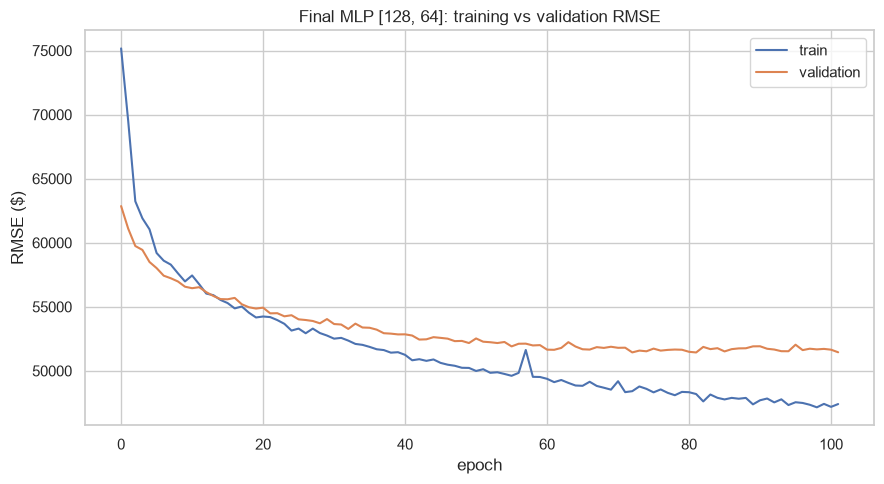


Final MLP TEST: R²=0.806  RMSE=51,921  MAE=34,485
Saved ../models/MLP_model.keras (final, search-selected)
MLP results updated with final searched model.


In [40]:
# Retrain the searched best architecture on the full training set, evaluate on
# the test set, save as the final deliverable, and store its metrics.

tf.random.set_seed(RANDOM_STATE)
mlp_final = make_mlp(best_cfg["layers"], best_cfg["lr"], best_cfg["dropout"])

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=20, restore_best_weights=True, verbose=0
)

history_final = mlp_final.fit(
    X_tr, y_tr_scaled,
    validation_split=0.2,
    epochs=300,
    batch_size=64,
    callbacks=[early_stop],
    verbose=0
)

stopped = len(history_final.history["loss"])
ftr = np.sqrt(history_final.history["loss"][-1]) * target_std
fval = np.sqrt(history_final.history["val_loss"][-1]) * target_std
print(f"Final MLP trained: stopped at epoch {stopped}")
print(f"Train RMSE: {ftr:,.0f} | Val RMSE: {fval:,.0f} | gap: {abs(fval-ftr):,.0f}")

# Final-training loss curve.
plt.figure(figsize=(9, 5))
plt.plot(np.sqrt(history_final.history["loss"]) * target_std, label="train")
plt.plot(np.sqrt(history_final.history["val_loss"]) * target_std, label="validation")
plt.title(f"Final MLP {best_cfg['layers']}: training vs validation RMSE")
plt.xlabel("epoch"); plt.ylabel("RMSE ($)"); plt.legend()
plt.tight_layout()
plt.savefig("../figures/mlp_final_curves.png", dpi=150, bbox_inches="tight")
plt.show()

# Test evaluation + overwrite the stored MLP results with the final model.
final_pred = mlp_predict_dollars(mlp_final, X_te)
print(f"\nFinal MLP TEST: R²={r2_score(y_te, final_pred):.3f}  "
      f"RMSE={np.sqrt(mean_squared_error(y_te, final_pred)):,.0f}  "
      f"MAE={mean_absolute_error(y_te, final_pred):,.0f}")

mlp_final.save("../models/MLP_model.keras")
print("Saved ../models/MLP_model.keras (final, search-selected)")

results["MLP"] = {
    "model": mlp_final,
    "r2_test":   r2_score(y_te, final_pred),
    "rmse_test": np.sqrt(mean_squared_error(y_te, final_pred)),
    "mae_test":  mean_absolute_error(y_te, final_pred),
    "pred_test": final_pred,
    "r2_train":  r2_score(y_tr, mlp_predict_dollars(mlp_final, X_tr)),
    "rmse_train": np.sqrt(mean_squared_error(y_tr, mlp_predict_dollars(mlp_final, X_tr))),
}
print("MLP results updated with final searched model.")


### 10d. Final Comparison: MLP vs Classical Models

Consolidate all four models and compare on accuracy (R², RMSE, MAE), generalisation (train/test gap), and computational cost.

In [41]:
# Unified four-model comparison table (test set, ranked by R²).

final_rows = []
for name in ["LR", "RFR", "SVR", "MLP"]:
    r = results[name]
    final_rows.append({
        "Model": name,
        "R2_test":   round(r["r2_test"], 3),
        "RMSE_test": round(r["rmse_test"]),
        "MAE_test":  round(r["mae_test"]),
        "R2_train":  round(r["r2_train"], 3),
        "R2_gap":    round(r["r2_train"] - r["r2_test"], 3),
    })

final_table = pd.DataFrame(final_rows).set_index("Model")
final_table = final_table.sort_values("R2_test", ascending=False)
print("FINAL MODEL COMPARISON (test set, ranked by R²):")
display(final_table)

final_table.to_csv("../figures/final_model_comparison.csv")
print("\nSaved to figures/final_model_comparison.csv")


FINAL MODEL COMPARISON (test set, ranked by R²):


,R2_test,RMSE_test,MAE_test,R2_train,R2_gap
Model,,,,,
RFR,0.824,49376,32100,0.973,0.149
MLP,0.806,51921,34485,0.840,0.034
SVR,0.784,54690,35360,0.830,0.045
LR,0.660,68647,49707,0.654,-0.006



Saved to figures/final_model_comparison.csv


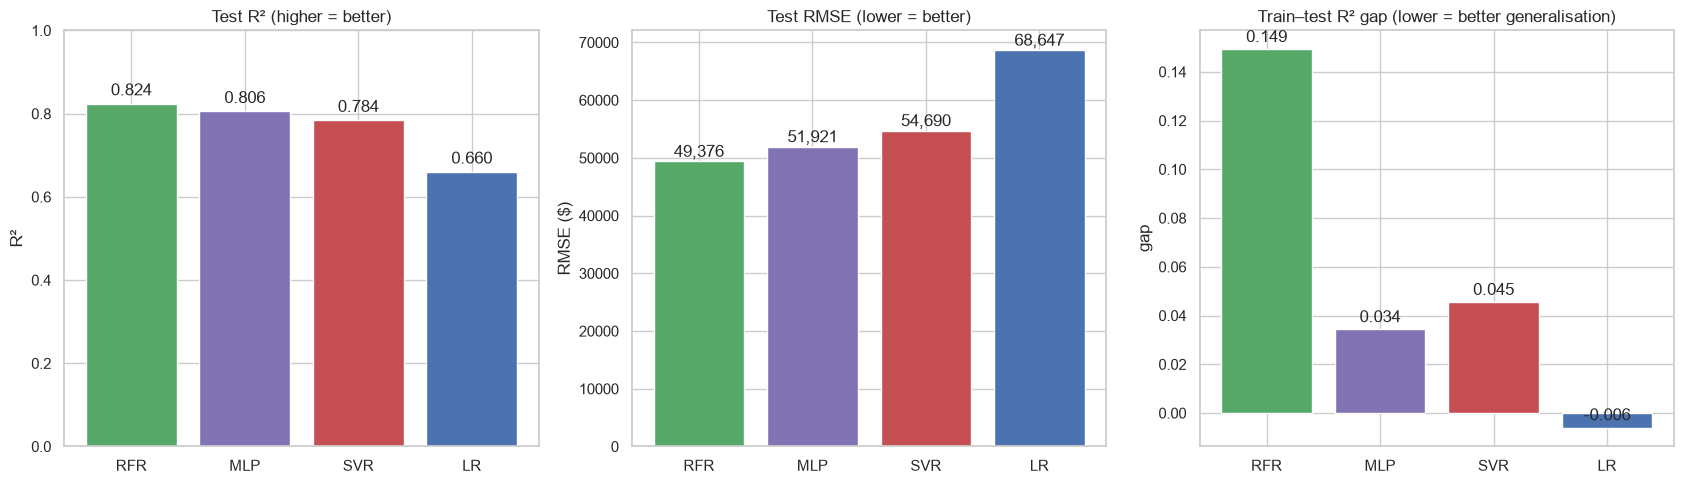

In [42]:
# Visual comparison: test R², test RMSE, and train/test R² gap.

models4 = list(final_table.index)
cols4 = {"LR": "#4C72B0", "RFR": "#55A868", "SVR": "#C44E52", "MLP": "#8172B3"}
bar_colours = [cols4[m] for m in models4]

fig, ax = plt.subplots(1, 3, figsize=(17, 5))

# Test R²
ax[0].bar(models4, [results[m]["r2_test"] for m in models4], color=bar_colours)
ax[0].set(title="Test R² (higher = better)", ylabel="R²", ylim=(0, 1))
for i, m in enumerate(models4):
    ax[0].text(i, results[m]["r2_test"] + 0.02, f'{results[m]["r2_test"]:.3f}', ha="center")

# Test RMSE
ax[1].bar(models4, [results[m]["rmse_test"] for m in models4], color=bar_colours)
ax[1].set(title="Test RMSE (lower = better)", ylabel="RMSE ($)")
for i, m in enumerate(models4):
    ax[1].text(i, results[m]["rmse_test"] + 800, f'{results[m]["rmse_test"]:,.0f}', ha="center")

# Train/test R² gap (overfitting)
gaps = [results[m]["r2_train"] - results[m]["r2_test"] for m in models4]
ax[2].bar(models4, gaps, color=bar_colours)
ax[2].set(title="Train–test R² gap (lower = better generalisation)", ylabel="gap")
for i, g in enumerate(gaps):
    ax[2].text(i, g + 0.003, f'{g:.3f}', ha="center")

plt.tight_layout()
plt.savefig("../figures/final_comparison_charts.png", dpi=150, bbox_inches="tight")
plt.show()
